In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [ ]:
def wrangle (file_path):
  """
  Reads a CSV file and returns a clean DataFrame.

  Parameters:
  file_path (str): The path to the CSV file.

  Returns:
  df (pandas.DataFrame): A clean DataFrame
  """
  df = pd.read_csv(file_path)

  # Converting 'tenure' to an int and cleaning the columns
  df['tenure'] = df['tenure'].astype(float)

  # Converting to Float
  df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)
  df[['TotalCharges', 'MonthlyCharges']] = df[['TotalCharges', 'MonthlyCharges']].astype(float)

  # Filling Missing Values with Specific Mean
  df.groupby('tenure')['TotalCharges'].mean().head()
  df[['TotalCharges','MonthlyCharges']] = df[['TotalCharges','MonthlyCharges']].fillna(
      df.groupby('tenure')['TotalCharges'].mean())

  # Converting Tenure from Month to Year
  df['tenure'] = round (df['tenure'] / 12, 2)

  # Segregating Customers by tenure
  def replace_values (column):
    if column < 1:
      return 'New'
    elif column <= 3:
      return 'Mid'
    elif column > 3:
      return 'Loyal'

  df['Customer Type'] = df['tenure'].apply(replace_values)

  # Creating a Mask for 'Multiple Lines' column
  mask = df['MultipleLines'].value_counts().head(2)
  df['MultipleLines'] = df ['MultipleLines'].apply(lambda x : x if x in mask else 'N/A')

  # Creating Number of times payments occurs
  df['Payment No'] = round (df['TotalCharges'] / df['MonthlyCharges'],2)

  # Columns to drop
  #drop_cols = ['customerID', 'MonthlyCharges', 'SeniorCitizen', 'StreamingTV', 'tenure']
  #df = df.drop(drop_cols, axis = 1)

  return df

In [ ]:
df = wrangle(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Payment No
0,7590-VHVEG,Female,0,Yes,No,0.08,No,N/A,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1.00
1,5575-GNVDE,Male,0,No,No,2.83,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,33.18
2,3668-QPYBK,Male,0,No,No,0.17,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2.01
3,7795-CFOCW,Male,0,No,No,3.75,No,N/A,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,43.52
4,9237-HQITU,Female,0,No,No,0.17,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2.14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: xlabel='PhoneService', ylabel='tenure'>

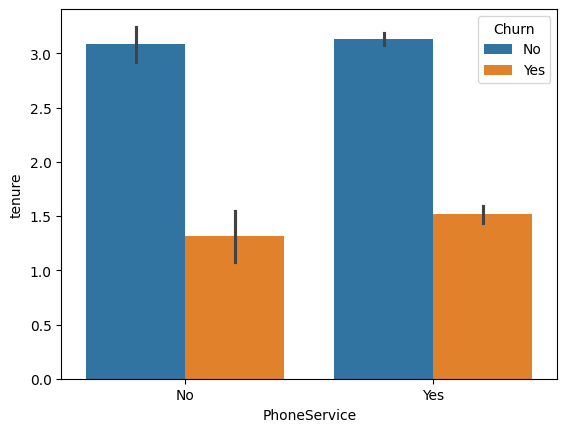

In [ ]:
sns.barplot(
    data=df,
    x='PhoneService',
    y='tenure',
    hue='Churn'
)

<Axes: xlabel='gender', ylabel='tenure'>

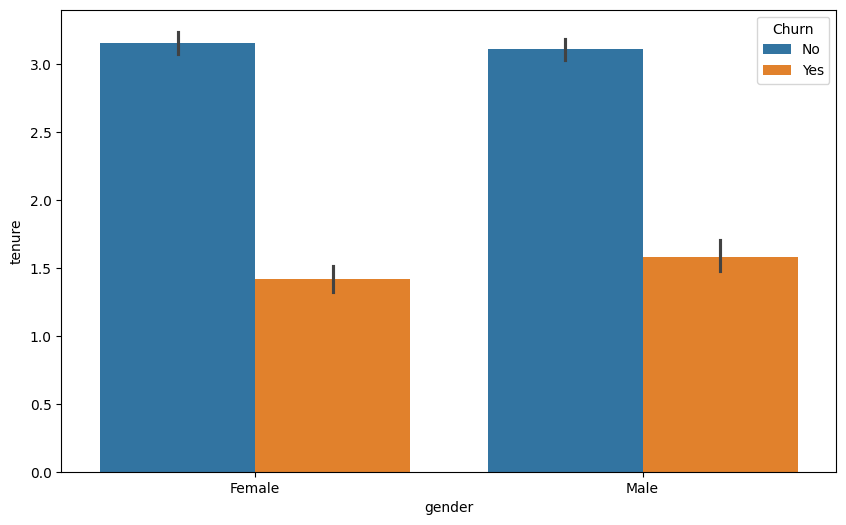

In [ ]:
fig, ax = plt.subplots (figsize = (10,6))
sns.barplot(
    data=df,
    x='gender',
    y='tenure',
    hue = 'Churn',
    ax = ax
    )

<Axes: xlabel='MultipleLines', ylabel='tenure'>

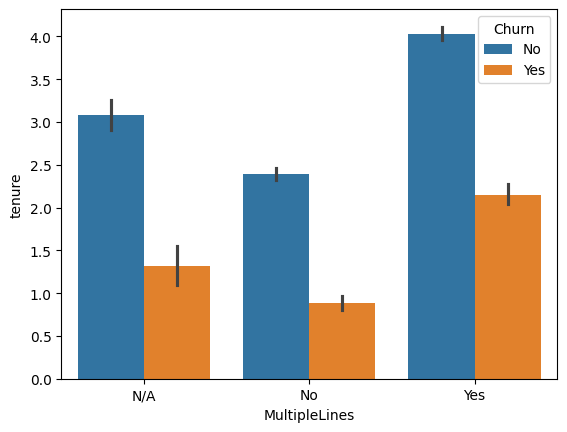

In [ ]:
sns.barplot(
    data=df,
    x='MultipleLines',
    y='tenure',
    hue='Churn'
)

<Axes: xlabel='InternetService', ylabel='tenure'>

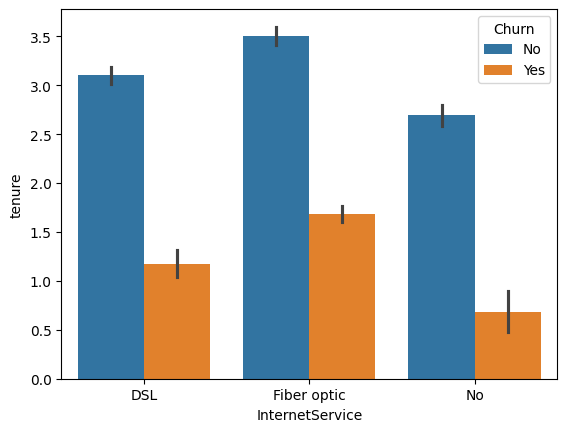

In [ ]:
sns.barplot(
    data=df,
    x='InternetService',
    y='tenure',
    hue='Churn'
)

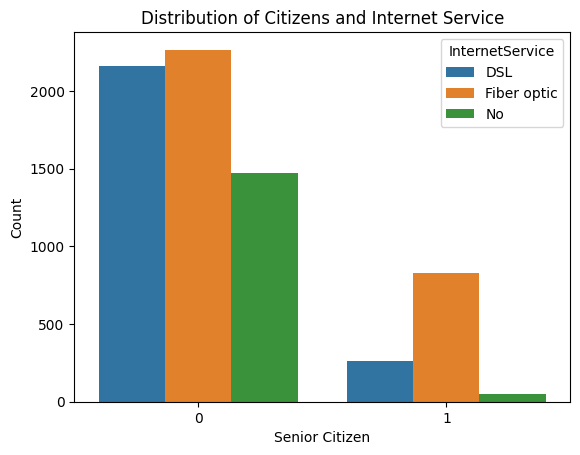

In [ ]:
sns.countplot(
    data = df,
    x = 'SeniorCitizen',
    hue = 'InternetService'
)


plt.title('Distribution of Citizens and Internet Service')
plt.xlabel('Senior Citizen')
plt.ylabel('Count');

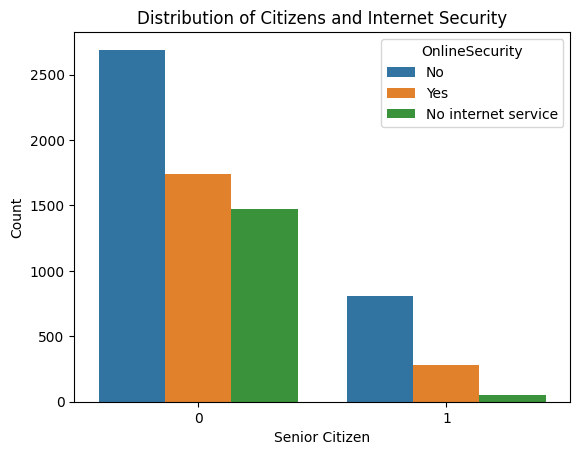

In [ ]:
sns.countplot(
    data = df,
    x = 'SeniorCitizen',
    hue = 'OnlineSecurity'
)


plt.title('Distribution of Citizens and Internet Security')
plt.xlabel('Senior Citizen')
plt.ylabel('Count');

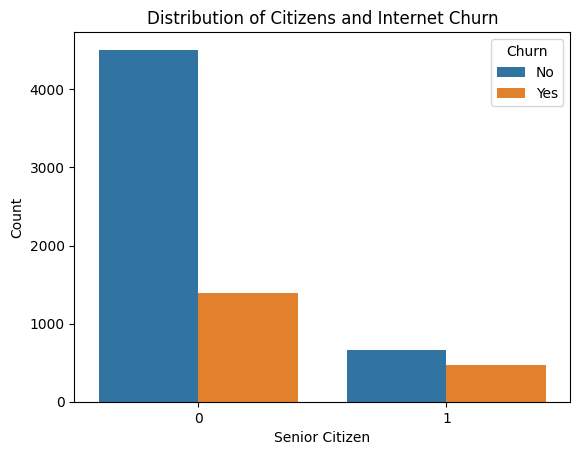

In [ ]:
sns.countplot(
    data = df,
    x = 'SeniorCitizen',
    hue = 'Churn'
)


plt.title('Distribution of Citizens and Internet Churn')
plt.xlabel('Senior Citizen')
plt.ylabel('Count');

In [ ]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


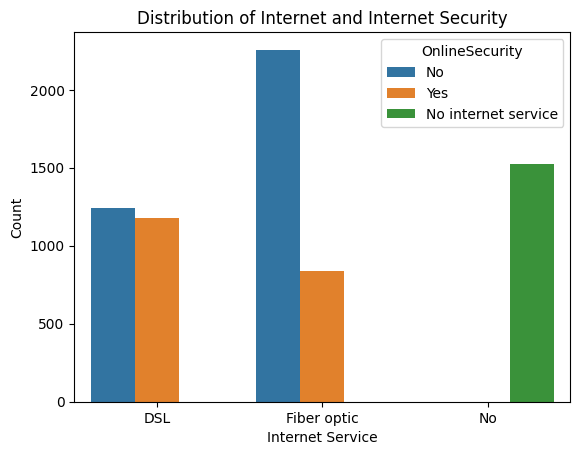

In [ ]:
sns.countplot(
    data = df,
    x = 'InternetService',
    hue = 'OnlineSecurity'
)


plt.title('Distribution of Internet and Internet Security')
plt.xlabel('Internet Service')
plt.ylabel('Count');

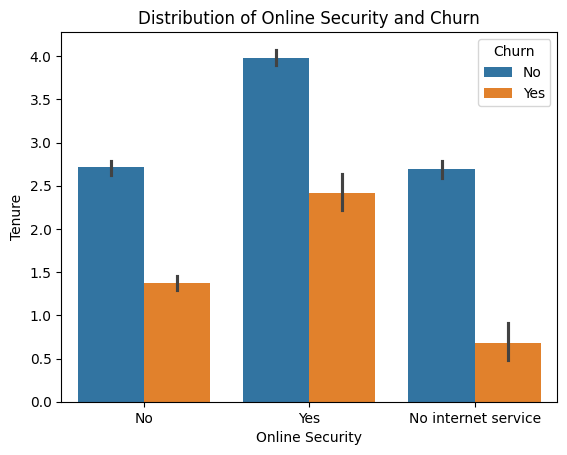

In [ ]:
sns.barplot(
    data = df,
    x = 'OnlineSecurity',
    y = 'tenure',
    hue = 'Churn'
)


plt.title('Distribution of Online Security and Churn')
plt.xlabel('Online Security')
plt.ylabel('Tenure');

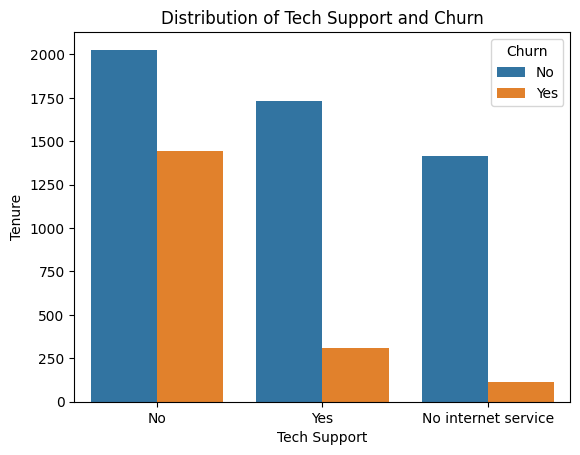

In [ ]:
sns.countplot(
    data = df,
    x = 'TechSupport',
    hue = 'Churn'
)


plt.title('Distribution of Tech Support and Churn')
plt.xlabel('Tech Support')
plt.ylabel('Tenure');

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Payment No
0,7590-VHVEG,Female,0,Yes,No,0.08,No,N/A,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1.00
1,5575-GNVDE,Male,0,No,No,2.83,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,33.18
2,3668-QPYBK,Male,0,No,No,0.17,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2.01
3,7795-CFOCW,Male,0,No,No,3.75,No,N/A,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,43.52
4,9237-HQITU,Female,0,No,No,0.17,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2.14


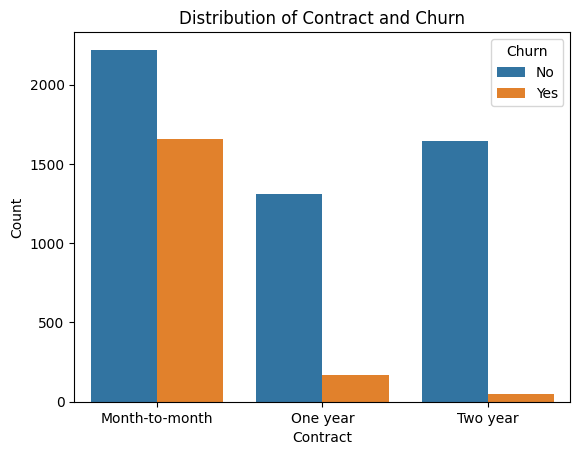

In [ ]:
sns.countplot(
    data = df,
    x = 'Contract',
    hue = 'Churn'
    )
plt.title('Distribution of Contract and Churn')
plt.xlabel('Contract')
plt.ylabel('Count');

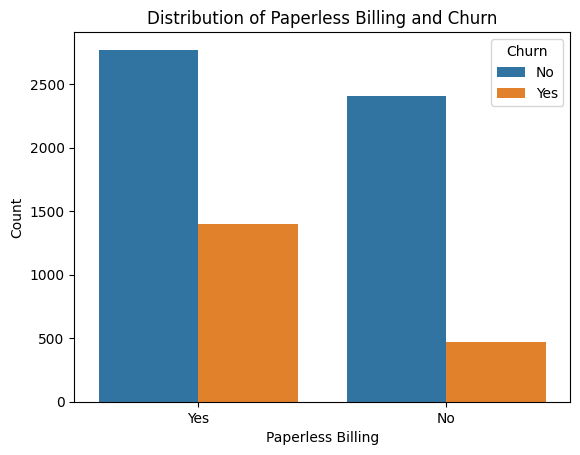

In [ ]:
sns.countplot(
    data = df,
    x = 'PaperlessBilling',
    hue = 'Churn'
    )
plt.title('Distribution of Paperless Billing and Churn')
plt.xlabel('Paperless Billing')
plt.ylabel('Count');

In [ ]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


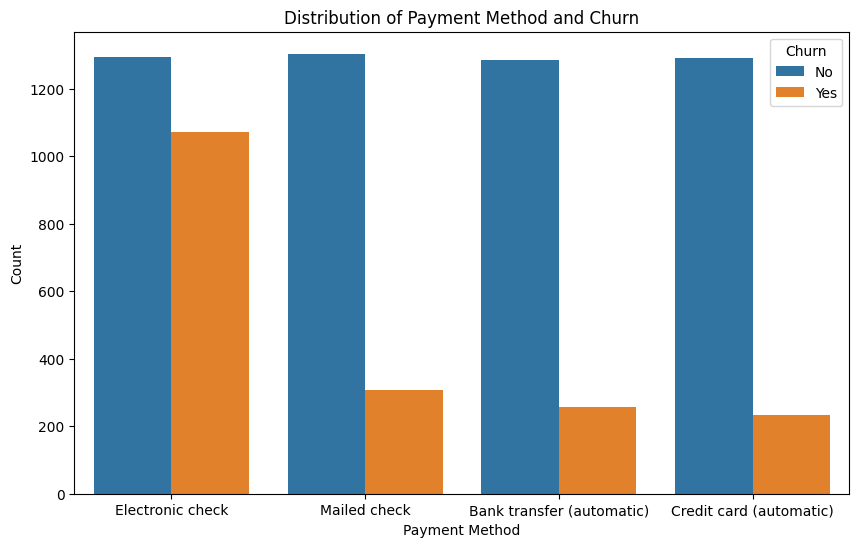

In [ ]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.countplot(
    data = df,
    x = 'PaymentMethod',
    hue = 'Churn',
    ax = ax
    )
plt.title('Distribution of Payment Method and Churn')
plt.xlabel('Payment Method')
plt.ylabel('Count');

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Payment No
SeniorCitizen,1.000000,0.016605,0.220173,0.103006,0.016184
tenure,0.016605,1.000000,0.247923,0.826170,0.998932
MonthlyCharges,0.220173,0.247923,1.000000,0.651174,0.247540
TotalCharges,0.103006,0.826170,0.651174,1.000000,0.826457
Payment No,0.016184,0.998932,0.247540,0.826457,1.000000


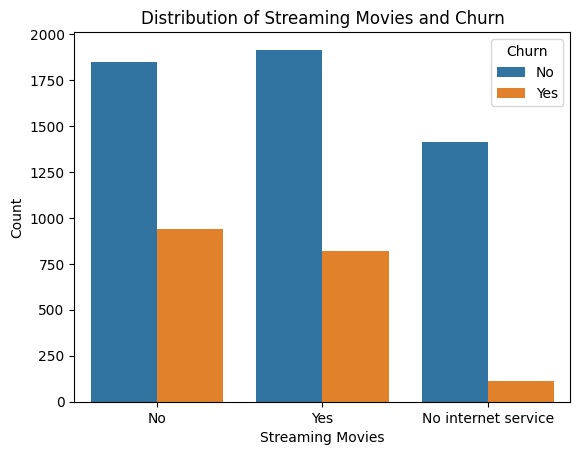

In [ ]:
sns.countplot(
    data = df,
    x = 'StreamingMovies',
    hue = 'Churn'
    )
plt.title('Distribution of Streaming Movies and Churn')
plt.xlabel('Streaming Movies')
plt.ylabel('Count');

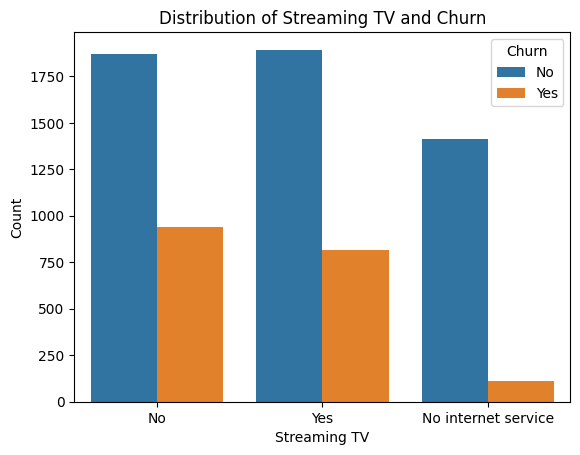

In [ ]:
sns.countplot(
    data = df,
    x = 'StreamingTV',
    hue = 'Churn'
)
plt.title('Distribution of Streaming TV and Churn')
plt.xlabel('Streaming TV')
plt.ylabel('Count');

In [ ]:
df['StreamingTV'] = df['StreamingTV'].map({'Yes': 1, 'No': 0, 'No internet service' : -1})
df['StreamingMovies'] = df['StreamingMovies'].map({'Yes': 1, 'No': 0, 'No internet service' : -1})
df['StreamingMovies'].corr(df['StreamingTV'])

np.float64(0.8072211792996967)

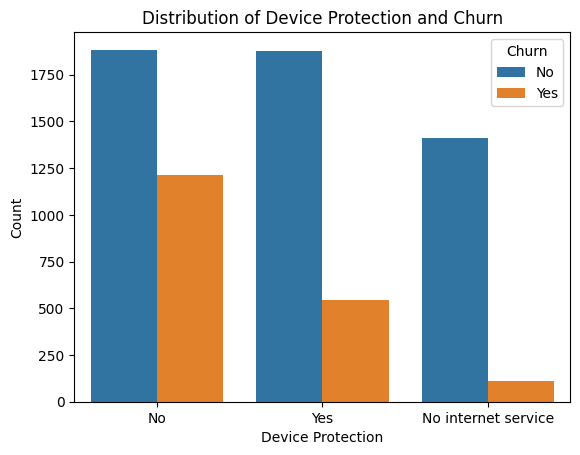

In [ ]:
sns.countplot(
    data = df,
    x = 'DeviceProtection',
    hue = 'Churn'
)
plt.title('Distribution of Device Protection and Churn')
plt.xlabel('Device Protection')
plt.ylabel('Count');

<Axes: >

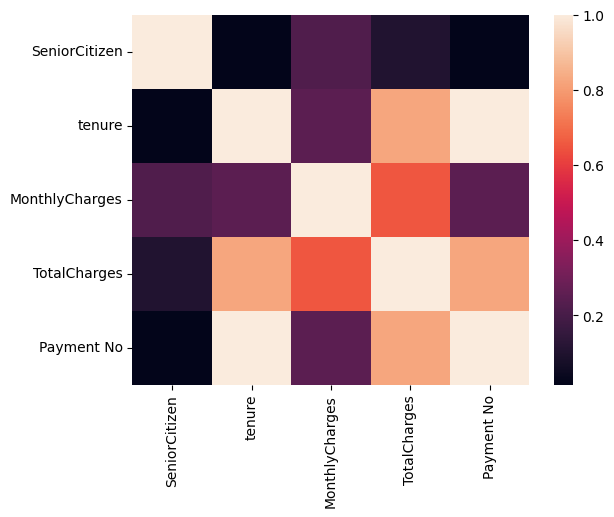

In [ ]:
sns.heatmap(df.corr(numeric_only=True))

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Payment No
0,7590-VHVEG,Female,0,Yes,No,0.08,No,N/A,DSL,No,...,No,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No,1.00
1,5575-GNVDE,Male,0,No,No,2.83,Yes,No,DSL,Yes,...,No,0,0,One year,No,Mailed check,56.95,1889.50,No,33.18
2,3668-QPYBK,Male,0,No,No,0.17,Yes,No,DSL,Yes,...,No,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2.01
3,7795-CFOCW,Male,0,No,No,3.75,No,N/A,DSL,Yes,...,Yes,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No,43.52
4,9237-HQITU,Female,0,No,No,0.17,Yes,No,Fiber optic,No,...,No,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2.14


In [ ]:
df['TechSupport'].value_counts()

,count
TechSupport,
No,3473
Yes,2044
No internet service,1526


In [ ]:
df['tenure'].describe()

,tenure
count,7043.000000
mean,2.697402
std,2.046968
min,0.000000
25%,0.750000
50%,2.420000
75%,4.580000
max,6.000000


In [ ]:
def replace_values (column):
  if column < 1:
    return 'New'
  elif column <= 3:
    return 'Mid'
  elif column > 3:
    return 'Loyal'

df['Customer Type'] = df['tenure'].apply(replace_values)

df['Customer Type'].value_counts()

,count
Customer Type,
Loyal,3001
New,2069
Mid,1973
